# Bounding box detection - Racoon data


## Data files
- images_racoon.rar: contain images of racoons
- train_labels.cv: contains coordinates for bounding box for every image

### Import the necessary libraries

In [1]:
import tensorflow as tf
import csv
import numpy as np
from PIL import Image

from keras import Model
from keras.applications.mobilenet import MobileNet, preprocess_input
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
from keras.layers import Conv2D, Reshape
from keras.utils import Sequence
from keras.backend import epsilon
import pandas as pd
import tensorflow
import keras

Using TensorFlow backend.


### Change directory

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load the training data from train.csv file

In [0]:
TRAIN_CSV = '/content/drive/My Drive/train_labels.csv'

In [0]:
with open(TRAIN_CSV,'r') as f:
    with open("/content/drive/My Drive/updated_train_labels.csv",'w') as f1:
        next(f) # skip header line
        for line in f:
            f1.write(line)
            
TRAIN_CSV = "/content/drive/My Drive/updated_train_labels.csv"

### Print the shape of the train dataset

In [13]:
batch_images.shape

(173, 128, 128, 3)

### Declare a variable IMAGE_SIZE = 128 as we will be using MobileNet which will be taking Input shape as 128 * 128 

In [0]:
IMAGE_SIZE = 128

### With the help of csv.reader write a for loop which can load the train.csv file and store the path, width, height, x0,y0,x1,y1 in induvidual variables. <br>
1. Create a list variable known as 'path' which has all the path for all the training images
2. Create an array 'coords' which has the resized coordinates of the bounding box for the training images

<u>Note:</u> All the training images should be downsampled to 128 * 128 as it is the input shape of MobileNet (which we will be using for Object detection). Hence the corresponding coordinates of the bounding boxes should be changed to match the image dimension of 128 * 128 

In [0]:
import csv
with open(TRAIN_CSV, 'r') as csvfile:
    paths = []
    coords = np.zeros((sum(1 for line in csvfile), 4))
    reader = csv.reader(csvfile, delimiter=',')
    csvfile.seek(0)
    for col, row in enumerate(reader):
               
        for i, r in enumerate(row[1:8]): # Parse row with seven entities
            if (i!=2):
                row[i+1] = int(r)
                
            
              
        path, image_width,image_height,image_class, x0, y0, x1, y1 = row  
       # path = "./" + path.split('/')[-2] + "/" + path.split('/')[-1]
        coords[col, 0] = x0 * IMAGE_SIZE / image_width # Normalize bounding box by image size
        coords[col, 1] = y0 * IMAGE_SIZE / image_height # Normalize bounding box by image size
        coords[col, 2] = (x1 - x0) * IMAGE_SIZE / image_width # Normalize bounding box by image size
        coords[col, 3] = (y1 - y0) * IMAGE_SIZE / image_height
        paths.append(path)

### Write a for loop which can load all the training images into a variable 'batch_images' using the paths from the 'paths' variable
<u>Note:</u> Convert the image to RGB scale as the MobileNet accepts 3 channels as inputs   

In [8]:
batch_images = np.zeros((len(paths), IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.float32)
for i,f in enumerate(paths):
    print('i is ',i)
    print('F is ',f)
    
    img = Image.open('/content/drive/My Drive/images/' + f) # Read image
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE)) # Resize image
    img = img.convert('RGB')
    batch_images[i] = preprocess_input(np.array(img, dtype=np.float32))

i is  0
F is  raccoon-17.jpg
i is  1
F is  raccoon-11.jpg
i is  2
F is  raccoon-63.jpg
i is  3
F is  raccoon-63.jpg
i is  4
F is  raccoon-60.jpg
i is  5
F is  raccoon-69.jpg
i is  6
F is  raccoon-180.jpg
i is  7
F is  raccoon-200.jpg
i is  8
F is  raccoon-141.jpg
i is  9
F is  raccoon-19.jpg
i is  10
F is  raccoon-84.jpg
i is  11
F is  raccoon-124.jpg
i is  12
F is  raccoon-182.jpg
i is  13
F is  raccoon-111.jpg
i is  14
F is  raccoon-91.jpg
i is  15
F is  raccoon-79.jpg
i is  16
F is  raccoon-93.jpg
i is  17
F is  raccoon-20.jpg
i is  18
F is  raccoon-42.jpg
i is  19
F is  raccoon-139.jpg
i is  20
F is  raccoon-58.jpg
i is  21
F is  raccoon-71.jpg
i is  22
F is  raccoon-183.jpg
i is  23
F is  raccoon-1.jpg
i is  24
F is  raccoon-169.jpg
i is  25
F is  raccoon-82.jpg
i is  26
F is  raccoon-4.jpg
i is  27
F is  raccoon-101.jpg
i is  28
F is  raccoon-10.jpg
i is  29
F is  raccoon-166.jpg
i is  30
F is  raccoon-184.jpg
i is  31
F is  raccoon-38.jpg
i is  32
F is  raccoon-120.jpg
i is  33


### Import MobileNet and load MobileNet into a variable named 'model' which takes input shape of 128 * 128 * 3. Freeze all the layers. Add convolution and reshape layers at the end to ensure the output is 4 coordinates

In [9]:
ALPHA = 1.0 # Width hyper parameter for MobileNet (0.25, 0.5, 0.75, 1.0). Higher width means more accurate but slower
IMAGE_SIZE = 128 # MobileNet takes images of size 128*128*3 
EPOCHS = 10 # Number of epochs. I got decent performance with just 5.
BATCH_SIZE = 32 # Depends on your GPU or CPU RAM.

model = MobileNet(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, alpha=ALPHA) # Load pre-trained mobilenet
# Do not include classification (top) layer

# to freeze layers, except the new top layer, of course, which will be added below
for layer in model.layers:
    layer.trainable = False

# Add new top layer which is a conv layer of the same size as the previous layer so that only 4 coords of BBox can be output
x = model.layers[-1].output
x = Conv2D(4, kernel_size=4, name="coords")(x)
# In the line above kernel size should be 3 for img size 96, 4 for img size 128, 5 for img size 160 etc.
x = Reshape((4,))(x) # These are the 4 predicted coordinates of one BBox

model = Model(inputs=model.input, outputs=x)

### Define a custom loss function IoU which calculates Intersection Over Union

In [0]:
def loss(gt,pred):
    intersections = 0
    unions = 0
    diff_width = np.minimum(gt[:,0] + gt[:,2], pred[:,0] + pred[:,2]) - np.maximum(gt[:,0], pred[:,0])
    diff_height = np.minimum(gt[:,1] + gt[:,3], pred[:,1] + pred[:,3]) - np.maximum(gt[:,1], pred[:,1])
    intersection = diff_width * diff_height
    
    # Compute union
    area_gt = gt[:,2] * gt[:,3]
    area_pred = pred[:,2] * pred[:,3]
    union = area_gt + area_pred - intersection

#     Compute intersection and union over multiple boxes
    for j, _ in enumerate(union):
        if union[j] > 0 and intersection[j] > 0 and union[j] >= intersection[j]:
            intersections += intersection[j]
            unions += union[j]

    # Compute IOU. Use epsilon to prevent division by zero
    iou = np.round(intersections / (unions + epsilon()), 4)
    iou = iou.astype(np.float32)
    return iou

def IoU(y_true, y_pred):
    iou = tf.py_func(loss, [y_true, y_pred], tf.float32)
    return iou

### Write model.compile function & model.fit function with: <br>
1. Optimizer = Adam, Loss = 'mse' and metrics = IoU
2. Epochs = 30, batch_size = 32, verbose = 1

In [12]:
gt = coords
model.compile(optimizer='Adam', loss='mse', metrics=[IoU]) # Regression loss is MSE

#checkpoint = ModelCheckpoint("model-{val_iou:.2f}.h5", verbose=1, save_best_only=True,
#                              save_weights_only=True, mode="max", period=1) # Checkpoint best validation model
#stop = EarlyStopping(monitor="val_iou", patience=PATIENCE, mode="max") # Stop early, if the validation error deteriorates
#reduce_lr = ReduceLROnPlateau(monitor="val_iou", factor=0.2, patience=10, min_lr=1e-7, verbose=1, mode="max")
# Reduce learning rate if Validation IOU does not improve

model.fit(batch_images,gt,
            epochs=30,batch_size = 32,
            verbose=1)



Epoch 1/30
173/173 [==============================] - 7s 40ms/step - loss: 2807.1746 - IoU: 0.0908
Epoch 2/30
173/173 [==============================] - 5s 31ms/step - loss: 601.3256 - IoU: 0.4481
Epoch 3/30
173/173 [==============================] - 5s 30ms/step - loss: 686.1566 - IoU: 0.5391
Epoch 4/30
173/173 [==============================] - 5s 30ms/step - loss: 588.0084 - IoU: 0.5342
Epoch 5/30
173/173 [==============================] - 5s 28ms/step - loss: 370.9754 - IoU: 0.5731
Epoch 6/30
173/173 [==============================] - 5s 29ms/step - loss: 275.8821 - IoU: 0.5784
Epoch 7/30
173/173 [==============================] - 5s 29ms/step - loss: 239.8298 - IoU: 0.6070
Epoch 8/30
173/173 [==============================] - 5s 31ms/step - loss: 194.1862 - IoU: 0.6599
Epoch 9/30
173/173 [==============================] - 5s 28ms/step - loss: 162.4805 - IoU: 0.7000
Epoch 10/30
173/173 [==============================] - 5s 29ms/step - loss: 141.7541 - IoU: 0.7155
Epoch 11/30
173/

### Pick a test image from the given data

In [0]:
# Pick a test image, run model, show image, and show predicted bounding box overlaid on the image
import cv2
filename = '/content/drive/My Drive/images/raccoon-122.jpg'
unscaled = cv2.imread(filename) # Original image for display

### Resize the image to 128 * 128 and preprocess the image for the MobileNet model

In [0]:
image_height, image_width, _ = unscaled.shape
image = cv2.resize(unscaled, (IMAGE_SIZE, IMAGE_SIZE)) # Rescaled image to run the network
feat_scaled = preprocess_input(np.array(image, dtype=np.float32))

### Predict the coordinates of the bounding box for the given test image

In [0]:
region = model.predict(x=np.array([feat_scaled]))[0] # Predict the BBox

### Plot the test image using .imshow and draw a boundary box around the image with the coordinates obtained from the model

In [0]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

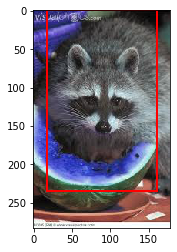

In [21]:
x0 = int(region[0] * image_width / IMAGE_SIZE) # Scale the BBox
y0 = int(region[1] * image_height / IMAGE_SIZE)

x1 = int((region[2]) * image_width / IMAGE_SIZE)
y1 = int((region[3]) * image_height / IMAGE_SIZE)


import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np


# Create figure and axes
fig,ax = plt.subplots(1)

# Display the image
ax.imshow(unscaled)

# Create a Rectangle patch
rect = patches.Rectangle((x0, y0), (x1 - x0) , (y1 - y0) , linewidth=2, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.show()